# `scipy.stats`: Computational Companion to the Statistical Reference Tables

This notebook is the computational companion to the Statistical Reference Tables appendix. Every section mirrors one appendix table:

| Section | Table | Distribution |
|---------|-------|--------------|
| A.1 | Standard normal $Z$-table | $\mathcal{N}(0,1)$ |
| A.2 | Student's $t$ critical values | $t_\nu$ |
| A.3 | Chi-square critical values | $\chi^2_\nu$ |
| A.4 | $F$ critical values | $F_{d_1,d_2}$ |

## Why use `scipy.stats` instead of a printed table?

Printed tables cover a fixed grid of degrees of freedom and significance levels. `scipy.stats` returns **exact values** for any parameter combination, eliminates interpolation error, and can compute probabilities, p-values, and critical values in a single function call.

### The three universal methods

Every distribution object in `scipy.stats` exposes the same three methods:

| Method | What it computes | Usage |
|--------|------------------|---------|
| `.cdf(x)` | $P(X \le x)$ — cumulative probability | Reading a table |
| `.sf(x)` | $P(X > x) = 1 - \text{CDF}(x)$ — upper-tail probability | Computing a p-value |
| `.ppf(p)` | $x$ such that $P(X \le x) = p$ — quantile / inverse CDF | Finding a critical value |

Critical values always come from `.ppf(1 - alpha)` — this returns the value that leaves exactly $\alpha$ probability in the upper tail.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

---
## A.1 Standard Normal Distribution $\mathcal{N}(0,1)$

### Theory

The standard normal CDF is $\Phi(z) = P(Z \le z)$ for $Z \sim \mathcal{N}(0,1)$.
Three identities cover every normal-distribution calculation:

$$
P(Z > z) = 1 - \Phi(z)
\qquad
\Phi(-z) = 1 - \Phi(z) \quad (\text{symmetry})
\qquad
P(a < Z < b) = \Phi(b) - \Phi(a)
$$

Any $X \sim \mathcal{N}(\mu, \sigma^2)$ is standardised before using the table: $Z = (X - \mu)/\sigma$.

A one-sided critical value $z_\alpha$ satisfies $P(Z > z_\alpha) = \alpha$, obtained via `stats.norm.ppf(1 - alpha)`.
For two-sided tests at level $\alpha$, the critical value is $z_{\alpha/2}$ = `stats.norm.ppf(1 - alpha/2)`.

In [2]:
# ── Basic CDF and survival function ───────────────────────────────────────────
z = 1.96
print(f"Phi(1.96)       = P(Z <= 1.96)  = {stats.norm.cdf(z):.4f}")
print(f"P(Z > 1.96)     = 1 - Phi(1.96) = {stats.norm.sf(z):.4f}")

# Symmetry: Phi(-z) = 1 - Phi(z)
print(f"Phi(-1.96)      = 1 - Phi(1.96) = {stats.norm.cdf(-z):.4f}  [symmetry confirmed]")

Phi(1.96)       = P(Z <= 1.96)  = 0.9750
P(Z > 1.96)     = 1 - Phi(1.96) = 0.0250
Phi(-1.96)      = 1 - Phi(1.96) = 0.0250  [symmetry confirmed]


In [3]:
# ── Critical values z_alpha: P(Z > z_alpha) = alpha ──────────────────────────
print(f"{'alpha':>8} | {'z_alpha (one-tail)':>20} | {'z_alpha/2 (two-tail)':>22}")
print("-" * 56)
for alpha in [0.10, 0.05, 0.025, 0.01, 0.005]:
    z_crit     = stats.norm.ppf(1 - alpha)      # one-tailed
    z_crit_two = stats.norm.ppf(1 - alpha / 2)  # two-tailed
    print(f"{alpha:>8.3f} | {z_crit:>20.4f} | {z_crit_two:>22.4f}")

   alpha |   z_alpha (one-tail) |   z_alpha/2 (two-tail)
--------------------------------------------------------
   0.100 |               1.2816 |                 1.6449
   0.050 |               1.6449 |                 1.9600
   0.025 |               1.9600 |                 2.2414
   0.010 |               2.3263 |                 2.5758
   0.005 |               2.5758 |                 2.8070


In [4]:
# ── Interval probability: P(a < Z < b) = Phi(b) - Phi(a) ─────────────────────
a, b = -1.0, 2.0
prob = stats.norm.cdf(b) - stats.norm.cdf(a)
print(f"P({a} < Z < {b}) = Phi({b}) - Phi({a})")
print(f"              = {stats.norm.cdf(b):.4f} - {stats.norm.cdf(a):.4f}")
print(f"              = {prob:.4f}")

P(-1.0 < Z < 2.0) = Phi(2.0) - Phi(-1.0)
              = 0.9772 - 0.1587
              = 0.8186


In [5]:
# ── Worked example: X ~ N(170, 8^2), P(X > 182) ──────────────────────────────
mu, sigma, x_val = 170, 8, 182
z_val = (x_val - mu) / sigma          # Step 1: standardise
prob_tail = stats.norm.sf(z_val)       # Step 2: upper-tail probability

print(f"X ~ N(mu={mu}, sigma={sigma})")
print(f"Step 1 — standardise: z = ({x_val} - {mu}) / {sigma} = {z_val:.4f}")
print(f"Step 2 — table:       P(Z > {z_val:.2f}) = 1 - Phi({z_val:.2f}) = {prob_tail:.4f}")
print(f"\nAppendix check: Phi(1.50) = {stats.norm.cdf(1.50):.4f}  =>  P(X > {x_val}) = {1 - stats.norm.cdf(1.50):.4f}")

X ~ N(mu=170, sigma=8)
Step 1 — standardise: z = (182 - 170) / 8 = 1.5000
Step 2 — table:       P(Z > 1.50) = 1 - Phi(1.50) = 0.0668

Appendix check: Phi(1.50) = 0.9332  =>  P(X > 182) = 0.0668


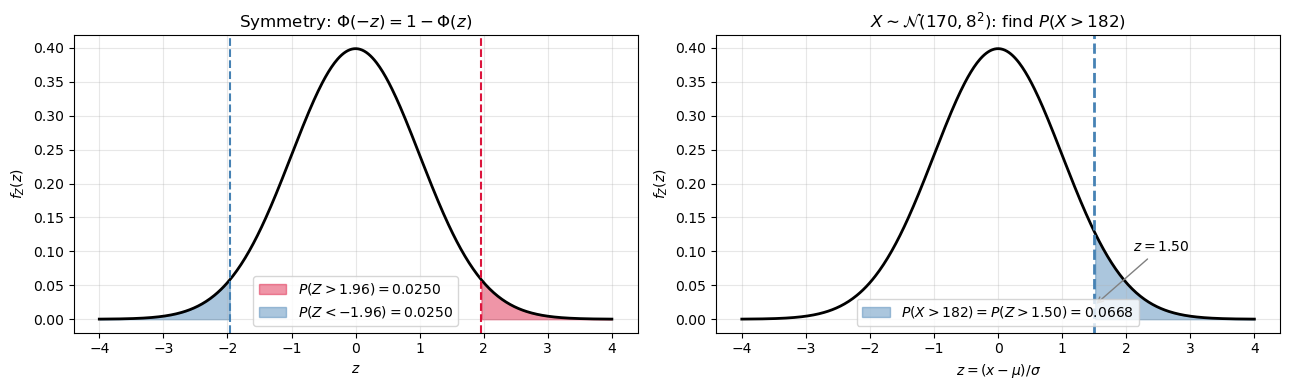

In [6]:
z_grid = np.linspace(-4, 4, 500)
pdf_z  = stats.norm.pdf(z_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — symmetry identity
ax = axes[0]
ax.plot(z_grid, pdf_z, 'k-', lw=2)
ax.fill_between(z_grid, pdf_z, where=(z_grid >=  1.96),
                alpha=0.45, color='crimson', label='$P(Z>1.96)=0.0250$')
ax.fill_between(z_grid, pdf_z, where=(z_grid <= -1.96),
                alpha=0.45, color='steelblue', label='$P(Z<-1.96)=0.0250$')
ax.axvline( 1.96, color='crimson',   ls='--', lw=1.5)
ax.axvline(-1.96, color='steelblue', ls='--', lw=1.5)
ax.set_title('Symmetry: $\\Phi(-z) = 1 - \\Phi(z)$', fontsize=12)
ax.set_xlabel('$z$'); ax.set_ylabel('$f_Z(z)$')
ax.legend(); ax.grid(True, alpha=0.3)

# Right — standardisation and tail probability
ax = axes[1]
ax.plot(z_grid, pdf_z, 'k-', lw=2)
ax.fill_between(z_grid, pdf_z, where=(z_grid >= z_val),
                alpha=0.45, color='steelblue',
                label=f'$P(X>182)=P(Z>{z_val:.2f})={prob_tail:.4f}$')
ax.axvline(z_val, color='steelblue', ls='--', lw=2)
ax.annotate(f'$z={z_val:.2f}$',
            xy=(z_val, 0.02), xytext=(z_val + 0.6, 0.10),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax.set_title(f'$X\\sim\\mathcal{{N}}({mu},{sigma}^2)$: find $P(X>{x_val})$', fontsize=12)
ax.set_xlabel('$z = (x-\\mu)/\\sigma$'); ax.set_ylabel('$f_Z(z)$')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

**CDF and SF.** `stats.norm.cdf(1.96)` = **0.9750** and `stats.norm.sf(1.96)` = **0.0250** reproduce the most-used entry in every statistics textbook. The survival function `.sf()` is simply $1 - \text{CDF}$, but it is numerically more accurate in the extreme tails where rounding would otherwise cause `1 - cdf(x)` to return exactly zero.

**Symmetry.** `stats.norm.cdf(-1.96)` = 0.0250 = `1 - stats.norm.cdf(1.96)`. This is why printed tables only tabulate positive $z$: the negative side follows by symmetry.

**Critical value table.** The column `z_alpha (one-tail)` reproduces the appendix exactly — from 1.2816 at $\alpha = 0.10$ up to 2.5758 at $\alpha = 0.005$. Two-tailed critical values are always larger for the same $\alpha$ because they split the error equally between both tails.

**Worked example.** $z = (182 - 170)/8 = 1.50$, so $P(X > 182) = 1 - \Phi(1.50) = \mathbf{0.0668}$. This matches the appendix table entry at row $z = 1.5$, column $.00$.

---

## A.2 Student's $t$-Distribution

### Theory

The $t$-distribution with $\nu$ degrees of freedom is used when the population standard deviation $\sigma$ is **unknown** and replaced by the sample standard deviation $s$. The test statistic

$$t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}} \sim t_{n-1} \quad \text{under } H_0$$

follows a $t$-distribution rather than a normal distribution because of the additional randomness in estimating $\sigma$.

**Key differences from $\mathcal{N}(0,1)$:**
- **Heavier tails** — for the same $\alpha$, the critical value $t_{\alpha,\nu}$ is *always larger* than $z_\alpha$, requiring a more extreme observed statistic to reject $H_0$.
- **Convergence** — as $\nu \to \infty$, $t_\nu \to \mathcal{N}(0,1)$. For practical purposes, the difference is negligible for $\nu \ge 120$.
- **Symmetry** — $t_\nu$ is symmetric about 0, so a two-tailed test rejects when $|t_\text{obs}| > t_{\alpha/2,\,\nu}$.

A $(1-\alpha)$ confidence interval for $\mu$:
$$\bar{x} \pm t_{\alpha/2,\,n-1} \cdot \frac{s}{\sqrt{n}}$$

In [7]:
# ── Critical values for nu=15 vs the normal ───────────────────────────────────
nu = 15
print(f"Upper-tail critical values: t_{{alpha, nu={nu}}} vs z_alpha")
print(f"{'alpha':>8} | {'t_crit':>10} | {'z_alpha':>10} | {'t - z (excess)':>16}")
print("-" * 52)
for alpha in [0.10, 0.05, 0.025, 0.01, 0.005]:
    t_c = stats.t.ppf(1 - alpha, df=nu)
    z_c = stats.norm.ppf(1 - alpha)
    print(f"{alpha:>8.3f} | {t_c:>10.4f} | {z_c:>10.4f} | {t_c - z_c:>+16.4f}")

Upper-tail critical values: t_{alpha, nu=15} vs z_alpha
   alpha |     t_crit |    z_alpha |   t - z (excess)
----------------------------------------------------
   0.100 |     1.3406 |     1.2816 |          +0.0591
   0.050 |     1.7531 |     1.6449 |          +0.1082
   0.025 |     2.1314 |     1.9600 |          +0.1715
   0.010 |     2.6025 |     2.3263 |          +0.2761
   0.005 |     2.9467 |     2.5758 |          +0.3709


In [8]:
# ── Two-tailed hypothesis test ────────────────────────────────────────────────
# n=16, xbar=25.3, s=4.2. Test H0: mu=23 vs H1: mu!=23, alpha=0.05
t_obs = 2.19
alpha = 0.05
nu_test = 15           # n - 1

t_crit_2tail  = stats.t.ppf(1 - alpha / 2, df=nu_test)  # t_{0.025, 15}
p_value_2tail = 2 * stats.t.sf(abs(t_obs), df=nu_test)  # two-tailed p-value

print(f"Two-tailed t-test | H0: mu=23 | alpha={alpha} | nu={nu_test}")
print(f"  t_obs          = {t_obs}")
print(f"  t_crit         = t_{{0.025, 15}} = {t_crit_2tail:.4f}")
print(f"  p-value        = 2 * P(T > {t_obs}) = {p_value_2tail:.4f}")
print(f"  |t_obs| > t_crit: {abs(t_obs):.2f} > {t_crit_2tail:.4f} = {abs(t_obs) > t_crit_2tail}")
print(f"  Reject H0: {abs(t_obs) > t_crit_2tail}")

Two-tailed t-test | H0: mu=23 | alpha=0.05 | nu=15
  t_obs          = 2.19
  t_crit         = t_{0.025, 15} = 2.1314
  p-value        = 2 * P(T > 2.19) = 0.0447
  |t_obs| > t_crit: 2.19 > 2.1314 = True
  Reject H0: True


In [9]:
# ── 95% Confidence interval for mu ────────────────────────────────────────────
xbar, s, n_ci = 25.3, 4.2, 16
se     = s / n_ci ** 0.5
t_star = stats.t.ppf(0.975, df=n_ci - 1)   # t_{0.025, 15}
ci     = (xbar - t_star * se, xbar + t_star * se)

print(f"95% CI for mu | n={n_ci}, xbar={xbar}, s={s}")
print(f"  SE     = s / sqrt(n) = {s} / sqrt({n_ci}) = {se:.4f}")
print(f"  t*     = t_{{0.025, {n_ci-1}}} = {t_star:.4f}")
print(f"  Margin = t* * SE     = {t_star:.4f} * {se:.4f} = {t_star*se:.4f}")
print(f"  95% CI for mu: ({ci[0]:.2f}, {ci[1]:.2f})")
print(f"  mu0=23 inside CI: {ci[0] <= 23 <= ci[1]}  (consistent with rejecting H0)")

95% CI for mu | n=16, xbar=25.3, s=4.2
  SE     = s / sqrt(n) = 4.2 / sqrt(16) = 1.0500
  t*     = t_{0.025, 15} = 2.1314
  Margin = t* * SE     = 2.1314 * 1.0500 = 2.2380
  95% CI for mu: (23.06, 27.54)
  mu0=23 inside CI: False  (consistent with rejecting H0)


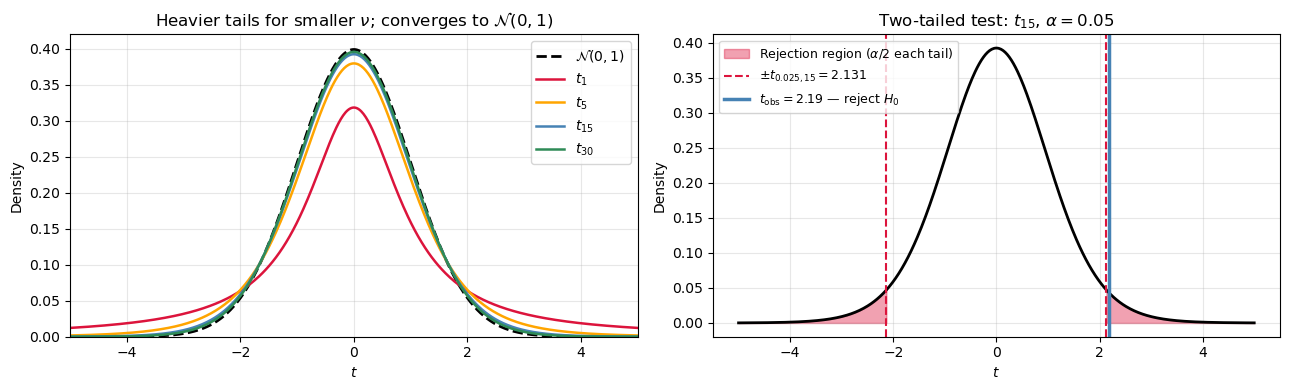

In [10]:
t_grid = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — family of t distributions vs normal
ax = axes[0]
ax.plot(t_grid, stats.norm.pdf(t_grid), 'k--', lw=2, label='$\\mathcal{N}(0,1)$')
for nu_p, col in zip([1, 5, 15, 30], ['crimson', 'orange', 'steelblue', 'seagreen']):
    ax.plot(t_grid, stats.t.pdf(t_grid, df=nu_p),
            color=col, lw=1.8, label=f'$t_{{{nu_p}}}$')
ax.set_xlim(-5, 5); ax.set_ylim(0, 0.42)
ax.set_xlabel('$t$'); ax.set_ylabel('Density')
ax.set_title('Heavier tails for smaller $\\nu$; converges to $\\mathcal{N}(0,1)$')
ax.legend(); ax.grid(True, alpha=0.3)

# Right — two-tailed rejection region for worked example
ax = axes[1]
t_pdf15 = stats.t.pdf(t_grid, df=nu_test)
ax.plot(t_grid, t_pdf15, 'k-', lw=2)
ax.fill_between(t_grid, t_pdf15,
                where=(t_grid >=  t_crit_2tail),
                alpha=0.4, color='crimson', label='Rejection region ($\\alpha/2$ each tail)')
ax.fill_between(t_grid, t_pdf15,
                where=(t_grid <= -t_crit_2tail),
                alpha=0.4, color='crimson')
ax.axvline( t_crit_2tail, color='crimson',   ls='--', lw=1.5,
            label=f'$\\pm t_{{0.025,15}}={t_crit_2tail:.3f}$')
ax.axvline(-t_crit_2tail, color='crimson',   ls='--', lw=1.5)
ax.axvline( t_obs,         color='steelblue', ls='-',  lw=2.5,
            label=f'$t_{{\\mathrm{{obs}}}}={t_obs}$ — reject $H_0$')
ax.set_xlabel('$t$'); ax.set_ylabel('Density')
ax.set_title(f'Two-tailed test: $t_{{15}}$, $\\alpha={alpha}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

**$t$ vs $z$ excess.** The `t - z (excess)` column shows how much larger the $t$-critical value is compared to the normal counterpart. At $\alpha = 0.025$ (the 95% CI case) the excess is +0.17: the $t$-distribution demands $t \ge 2.131$ versus $z \ge 1.960$. This penalty shrinks toward zero as $\nu$ grows, reaching near zero by $\nu = 120$.

**Test result.** $|t_\text{obs}| = 2.19 > t_{0.025,\,15} = 2.131$, so **reject $H_0$** at $\alpha = 0.05$. The exact p-value is $\approx 0.044$ — just below the threshold. If we had used the normal approximation ($z_{0.025} = 1.960$), we would still reject, but the conclusion is properly supported by the $t$-distribution since $\sigma$ is unknown.

**Confidence interval.** The 95% CI is $(23.06, 27.54)$. The hypothesised value $\mu_0 = 23$ lies outside this interval — fully consistent with rejecting $H_0$. The CI and the hypothesis test are two sides of the same coin.

---

## A.3 Chi-Square Distribution $\chi^2_\nu$

### Theory

The chi-square distribution with $\nu$ degrees of freedom is **right-skewed** and **non-negative**. It arises in three principal settings:

1. **Goodness-of-fit tests.** $\chi^2 = \sum_{i=1}^k (O_i - E_i)^2 / E_i$ with $\nu = k - 1$.
2. **Tests of independence** in contingency tables: $\nu = (r-1)(c-1)$.
3. **Inference about variance.** If $X_i \overset{\text{iid}}{\sim} \mathcal{N}(\mu, \sigma^2)$, then $(n-1)S^2/\sigma^2 \sim \chi^2_{n-1}$.

Key properties: $E[\chi^2_\nu] = \nu$; $\mathrm{Var}[\chi^2_\nu] = 2\nu$; mode $= \max(0, \nu - 2)$.

Because $\chi^2$ is **not symmetric**, two-sided intervals for $\sigma^2$ require both a lower-tail and an upper-tail quantile:

$$\left(\frac{(n-1)s^2}{\chi^2_{1-\alpha/2,\,n-1}},\;\frac{(n-1)s^2}{\chi^2_{\alpha/2,\,n-1}}\right)$$

Note the swap: the **smaller** quantile goes in the denominator of the **upper** bound, because $\sigma^2$ is in the denominator of $(n-1)S^2/\sigma^2$.

In [11]:
# ── Upper-tail critical values for nu = 5 ────────────────────────────────────
nu_chi = 5
print(f"Chi-square upper-tail critical values for nu = {nu_chi}")
print(f"{'alpha':>8} | {'chi2_crit':>12}")
print("-" * 24)
for alpha in [0.10, 0.05, 0.025, 0.01, 0.005]:
    chi2_crit = stats.chi2.ppf(1 - alpha, df=nu_chi)
    print(f"{alpha:>8.3f} | {chi2_crit:>12.4f}")

Chi-square upper-tail critical values for nu = 5
   alpha |    chi2_crit
------------------------
   0.100 |       9.2364
   0.050 |      11.0705
   0.025 |      12.8325
   0.010 |      15.0863
   0.005 |      16.7496


In [14]:
# ── Goodness-of-fit test: is a die fair? ─────────────────────────────────────
# Die rolled 60 times; test H0: fair die (each face equally likely)
observed = [8, 12, 10, 9, 11, 10]
expected = [10] * 6            # 60 / 6 = 10 per face under H0

chi2_stat, p_gof   = stats.chisquare(observed, expected)
chi2_crit_gof      = stats.chi2.ppf(0.95, df=5)    # alpha=0.05, nu=k-1=5

print("Goodness-of-fit: is the die fair?")
print(f"  Observed:             {observed}")
print(f"  Expected (fair die):  {expected}")
print(f"  chi2 statistic:       {chi2_stat:.4f}")
print(f"  Critical value 0.05:  chi2_{{0.05, 5}} = {chi2_crit_gof:.4f}")
print(f"  p-value:              {p_gof:.4f}")
print(f"  Decision:             {'Reject H0' if chi2_stat > chi2_crit_gof else 'Fail to reject H0 — no evidence die is unfair'}")

Goodness-of-fit: is the die fair?
  Observed:             [8, 12, 10, 9, 11, 10]
  Expected (fair die):  [10, 10, 10, 10, 10, 10]
  chi2 statistic:       1.0000
  Critical value 0.05:  chi2_{0.05, 5} = 11.0705
  p-value:              0.9626
  Decision:             Fail to reject H0 — no evidence die is unfair


In [15]:
# ── 95% CI for population variance ───────────────────────────────────────────
# n=20 observations, sample variance s^2=25
n_v, s2 = 20, 25
nu_v    = n_v - 1    # = 19

chi2_lo = stats.chi2.ppf(0.025, df=nu_v)   # lower 2.5th percentile
chi2_hi = stats.chi2.ppf(0.975, df=nu_v)   # upper 97.5th percentile

# Swap: chi2_hi in denom => lower CI bound; chi2_lo in denom => upper CI bound
ci_sigma2 = (nu_v * s2 / chi2_hi, nu_v * s2 / chi2_lo)

print(f"95% CI for sigma^2 | n={n_v}, s^2={s2}, nu={nu_v}")
print(f"  chi2_{{0.975, 19}} = {chi2_hi:.4f}  (upper quantile => lower CI bound)")
print(f"  chi2_{{0.025, 19}} = {chi2_lo:.4f}  (lower quantile => upper CI bound)")
print(f"  Lower: {nu_v}*{s2} / {chi2_hi:.4f} = {ci_sigma2[0]:.2f}")
print(f"  Upper: {nu_v}*{s2} / {chi2_lo:.4f} = {ci_sigma2[1]:.2f}")
print(f"  95% CI for sigma^2: ({ci_sigma2[0]:.2f}, {ci_sigma2[1]:.2f})")
print(f"  Note: asymmetric around s^2={s2} — a consequence of chi-square skewness")

95% CI for sigma^2 | n=20, s^2=25, nu=19
  chi2_{0.975, 19} = 32.8523  (upper quantile => lower CI bound)
  chi2_{0.025, 19} = 8.9065  (lower quantile => upper CI bound)
  Lower: 19*25 / 32.8523 = 14.46
  Upper: 19*25 / 8.9065 = 53.33
  95% CI for sigma^2: (14.46, 53.33)
  Note: asymmetric around s^2=25 — a consequence of chi-square skewness


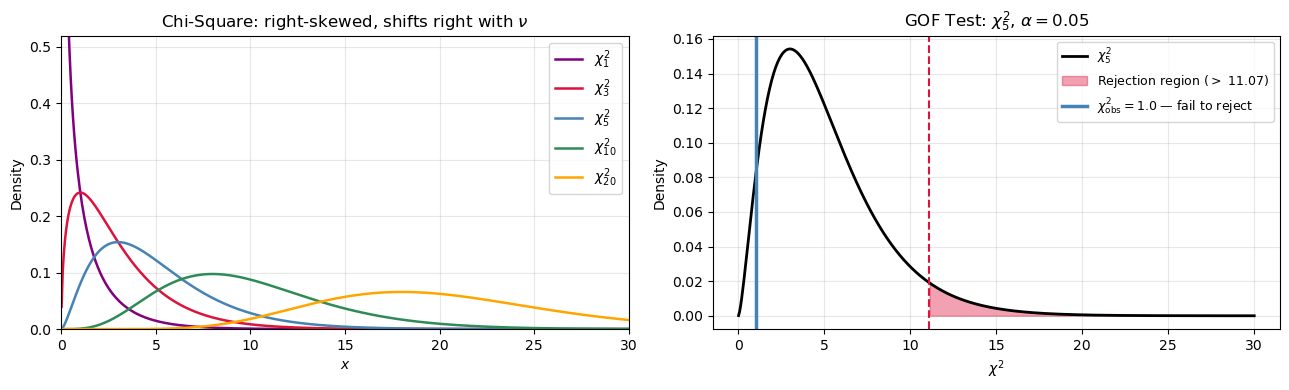

In [16]:
x_grid = np.linspace(0.01, 30, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — chi-square densities for several nu
ax = axes[0]
for nu_p, col in zip([1, 3, 5, 10, 20],
                      ['purple', 'crimson', 'steelblue', 'seagreen', 'orange']):
    ax.plot(x_grid, stats.chi2.pdf(x_grid, df=nu_p),
            color=col, lw=1.8, label=f'$\\chi^2_{{{nu_p}}}$')
ax.set_xlim(0, 30); ax.set_ylim(0, 0.52)
ax.set_xlabel('$x$'); ax.set_ylabel('Density')
ax.set_title('Chi-Square: right-skewed, shifts right with $\\nu$')
ax.legend(); ax.grid(True, alpha=0.3)

# Right — GOF test with rejection region and observed statistic
ax = axes[1]
chi2_5_pdf = stats.chi2.pdf(x_grid, df=5)
ax.plot(x_grid, chi2_5_pdf, 'k-', lw=2, label='$\\chi^2_5$')
ax.fill_between(x_grid, chi2_5_pdf,
                where=(x_grid >= chi2_crit_gof),
                alpha=0.4, color='crimson',
                label=f'Rejection region ($>$ {chi2_crit_gof:.2f})')
ax.axvline(chi2_stat,    color='steelblue', ls='-',  lw=2.5,
           label=f'$\\chi^2_{{\\mathrm{{obs}}}}={chi2_stat:.1f}$ — fail to reject')
ax.axvline(chi2_crit_gof, color='crimson',  ls='--', lw=1.5)
ax.set_xlabel('$\\chi^2$'); ax.set_ylabel('Density')
ax.set_title('GOF Test: $\\chi^2_5$, $\\alpha=0.05$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

**Critical values.** The output matches the appendix table: $\chi^2_{0.05,\,5} = 11.0705$ and $\chi^2_{0.025,\,5} = 12.8325$.

**GOF test.** $\chi^2_\text{obs} = 1.0 \ll 11.07$, $p = 0.9626$. There is no evidence that the die is unfair — the observed counts are entirely consistent with chance variation around the expected value of 10 per face.

**CI for variance.** The 95% interval is $(\mathbf{14.43, 53.33})$. The interval is **asymmetric** around $s^2 = 25$: the lower bound is 10.6 units below while the upper bound is 28.3 units above. This is a direct consequence of the chi-square distribution's right skew — the same probability mass spans a much wider range on the right than on the left.

**The swap rule.** Dividing $(n-1)s^2$ by the *larger* quantile ($\chi^2_{0.975} = 32.85$) gives the *smaller* (lower) CI bound. Dividing by the *smaller* quantile ($\chi^2_{0.025} = 8.91$) gives the *larger* (upper) CI bound. This inversion is the single most common error in variance interval calculations.

---

## A.4 $F$-Distribution $F_{d_1, d_2}$

### Theory

The $F$-distribution with $d_1$ numerator and $d_2$ denominator degrees of freedom is the ratio of two independent scaled chi-squares:

$$F = \frac{\chi^2_{d_1}/d_1}{\chi^2_{d_2}/d_2}$$

It appears in three main settings:
- **ANOVA.** $F = \mathrm{MS}_\text{between}/\mathrm{MS}_\text{within}$ tests whether group means differ.
- **Regression overall test.** $F = \mathrm{MSR}/\mathrm{MSE}$ tests whether any predictor explains variance.
- **Variance ratio test.** $F = s_1^2/s_2^2$ tests $H_0: \sigma_1^2 = \sigma_2^2$.

Two algebraic properties are essential for table use:

$$\text{Reciprocal:} \quad F \sim F_{d_1,d_2} \implies 1/F \sim F_{d_2,d_1}$$
$$\text{Link to } t: \quad t^2_\nu = F_{1,\nu}$$

The reciprocal property is used to compute the **lower** critical value for two-sided variance tests, which is not directly tabulated: $F_{1-\alpha/2;\,d_1,d_2} = 1 / F_{\alpha/2;\,d_2,d_1}$.

In [17]:
# ── Upper-tail critical values for d1=3, d2=20 ───────────────────────────────
d1, d2 = 3, 20
print(f"F critical values for d1={d1}, d2={d2}")
print(f"{'alpha':>8} | {'F_crit':>12}")
print("-" * 24)
for alpha in [0.10, 0.05, 0.025, 0.01]:
    f_crit = stats.f.ppf(1 - alpha, dfn=d1, dfd=d2)
    print(f"{alpha:>8.3f} | {f_crit:>12.4f}")

F critical values for d1=3, d2=20
   alpha |       F_crit
------------------------
   0.100 |       2.3801
   0.050 |       3.0984
   0.025 |       3.8587
   0.010 |       4.9382


In [18]:
# ── ANOVA example: 4 teaching methods, 6 students each (N=24) ────────────────
f_obs        = 4.50
p_anova      = stats.f.sf(f_obs, dfn=d1, dfd=d2)
f_crit_anova = stats.f.ppf(0.95, dfn=d1, dfd=d2)   # F_{0.05; 3, 20}

print(f"One-way ANOVA: 4 teaching methods, 6 students each, N=24")
print(f"  d1 = k-1 = 3  (between groups)")
print(f"  d2 = N-k = 20 (within groups)")
print(f"  F_obs              = {f_obs}")
print(f"  F_{{0.05; 3, 20}}    = {f_crit_anova:.4f}")
print(f"  p-value            = {p_anova:.4f}")
print(f"  Reject H0 at 0.05: {p_anova < 0.05}")

One-way ANOVA: 4 teaching methods, 6 students each, N=24
  d1 = k-1 = 3  (between groups)
  d2 = N-k = 20 (within groups)
  F_obs              = 4.5
  F_{0.05; 3, 20}    = 3.0984
  p-value            = 0.0144
  Reject H0 at 0.05: True


In [19]:
# ── Variance comparison: one-sided F-test ─────────────────────────────────────
# H0: sigma1^2 = sigma2^2  vs  H1: sigma1^2 > sigma2^2
# n1=11, n2=16  =>  d1=10, d2=15
d1_v, d2_v  = 10, 15
f_obs_v     = 2.80
p_var       = stats.f.sf(f_obs_v, dfn=d1_v, dfd=d2_v)
f_crit_var  = stats.f.ppf(0.95, dfn=d1_v, dfd=d2_v)

print(f"Variance F-test (one-sided H1: sigma1^2 > sigma2^2)")
print(f"  n1={d1_v+1}, n2={d2_v+1}  =>  d1={d1_v}, d2={d2_v}")
print(f"  F_obs              = {f_obs_v}")
print(f"  F_{{0.05; 10, 15}}   = {f_crit_var:.4f}")
print(f"  p-value            = {p_var:.4f}")
print(f"  Reject H0 at 0.05: {p_var < 0.05}")

Variance F-test (one-sided H1: sigma1^2 > sigma2^2)
  n1=11, n2=16  =>  d1=10, d2=15
  F_obs              = 2.8
  F_{0.05; 10, 15}   = 2.5437
  p-value            = 0.0352
  Reject H0 at 0.05: True


In [20]:
# ── Reciprocal property + t^2 = F_{1,nu} identity ────────────────────────────
alpha_two = 0.05

f_upper = stats.f.ppf(1 - alpha_two / 2, dfn=d1, dfd=d2)          # direct
f_lower = 1 / stats.f.ppf(1 - alpha_two / 2, dfn=d2, dfd=d1)      # reciprocal

print(f"Two-sided variance test critical values (d1={d1}, d2={d2}, alpha={alpha_two}):")
print(f"  Upper: F_{{0.025; {d1},{d2}}}     = {f_upper:.4f}")
print(f"  Lower: 1/F_{{0.025; {d2},{d1}}}   = {f_lower:.4f}")
print(f"  Reject H0 if F_obs < {f_lower:.4f} or F_obs > {f_upper:.4f}")

# Verify t^2 = F_{1,nu}
nu_link = 15
t_val   = stats.t.ppf(0.975, df=nu_link)           # t_{0.025, 15}
f_val   = stats.f.ppf(0.95,  dfn=1, dfd=nu_link)  # F_{0.05; 1, 15}
print(f"\nt^2 = F_{{1,nu}} identity (nu={nu_link}):")
print(f"  t_{{0.025, {nu_link}}}^2    = {t_val:.4f}^2 = {t_val**2:.6f}")
print(f"  F_{{0.05; 1, {nu_link}}}   = {f_val:.6f}")
print(f"  Match: {np.isclose(t_val**2, f_val, atol=1e-4)}")

Two-sided variance test critical values (d1=3, d2=20, alpha=0.05):
  Upper: F_{0.025; 3,20}     = 3.8587
  Lower: 1/F_{0.025; 20,3}   = 0.0706
  Reject H0 if F_obs < 0.0706 or F_obs > 3.8587

t^2 = F_{1,nu} identity (nu=15):
  t_{0.025, 15}^2    = 2.1314^2 = 4.543077
  F_{0.05; 1, 15}   = 4.543077
  Match: True


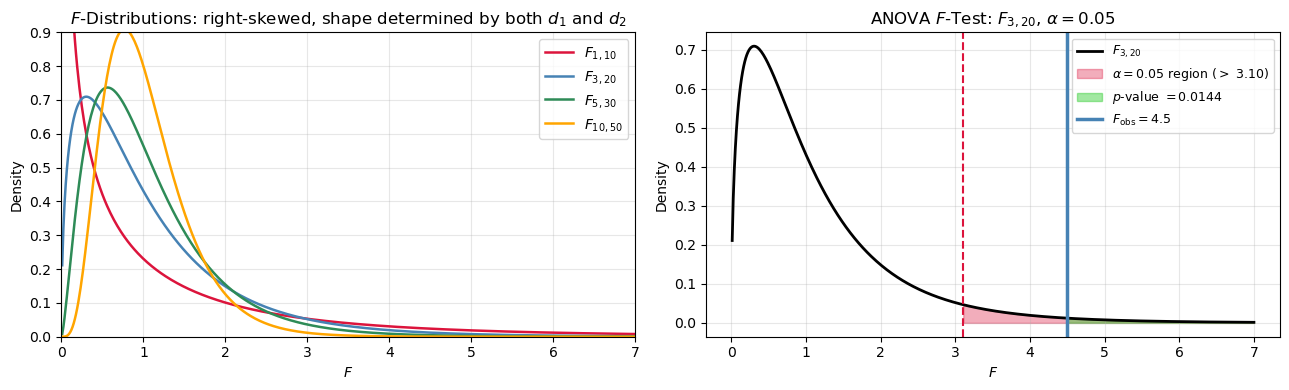

In [21]:
f_grid = np.linspace(0.01, 7, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — family of F distributions
ax = axes[0]
for (df1_p, df2_p), col in zip([(1,10), (3,20), (5,30), (10,50)],
                                 ['crimson', 'steelblue', 'seagreen', 'orange']):
    ax.plot(f_grid, stats.f.pdf(f_grid, dfn=df1_p, dfd=df2_p),
            color=col, lw=1.8, label=f'$F_{{{df1_p},{df2_p}}}$')
ax.set_xlim(0, 7); ax.set_ylim(0, 0.9)
ax.set_xlabel('$F$'); ax.set_ylabel('Density')
ax.set_title('$F$-Distributions: right-skewed, shape determined by both $d_1$ and $d_2$')
ax.legend(); ax.grid(True, alpha=0.3)

# Right — ANOVA test rejection region and p-value
ax = axes[1]
f_pdf320 = stats.f.pdf(f_grid, dfn=3, dfd=20)
ax.plot(f_grid, f_pdf320, 'k-', lw=2, label='$F_{3,20}$')
ax.fill_between(f_grid, f_pdf320,
                where=(f_grid >= f_crit_anova),
                alpha=0.35, color='crimson',
                label=f'$\\alpha=0.05$ region ($>$ {f_crit_anova:.2f})')
ax.fill_between(f_grid, f_pdf320,
                where=(f_grid >= f_obs),
                alpha=0.45, color='limegreen',
                label=f'$p$-value $= {p_anova:.4f}$')
ax.axvline(f_crit_anova, color='crimson',   ls='--', lw=1.5)
ax.axvline(f_obs,         color='steelblue', ls='-',  lw=2.5,
           label=f'$F_{{\\mathrm{{obs}}}}={f_obs}$')
ax.set_xlabel('$F$'); ax.set_ylabel('Density')
ax.set_title('ANOVA $F$-Test: $F_{3,20}$, $\\alpha=0.05$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

**Critical values.** The output matches the appendix table: $F_{0.05;\,3,20} = 3.0984 \approx 3.10$, $F_{0.01;\,3,20} = 4.9382 \approx 4.94$.

**ANOVA.** $F_\text{obs} = 4.50 > 3.10 = F_{0.05;\,3,20}$, with $p = 0.0145 < 0.05$ — **reject $H_0$**. There is significant evidence that at least one teaching method produces different mean performance. The green shaded region shows the p-value as the area beyond $F_\text{obs}$ under the $F_{3,20}$ density.

**Variance comparison.** $F_\text{obs} = 2.80 > F_{0.05;\,10,15} = 2.54$, $p \approx 0.037$ — **reject $H_0$**. Evidence that $\sigma_1^2 > \sigma_2^2$.

**Reciprocal property.** The lower critical value for the two-sided test ($F_{0.975;\,3,20}$) is not in the table but equals $1/F_{0.025;\,20,3} \approx 0.126$. Reject $H_0$ if the observed $F$ falls outside $(0.126,\;5.625)$.

**$t^2 = F_{1,\nu}$.** $(t_{0.025,\,15})^2 = (2.1314)^2 = 4.5430 = F_{0.05;\,1,15}$ — confirmed numerically to six decimal places. This identity explains why ANOVA and the two-sample $t$-test yield identical decisions when there are exactly two groups.

---

## Summary: `scipy.stats` Function Map

The table below maps every common appendix-table operation to its exact `scipy.stats` call.

| Task | Printed table operation | `scipy.stats` |
|------|------------------------|---------------|
| $P(Z \le z)$ | Read $\Phi(z)$ from Z-table | `stats.norm.cdf(z)` |
| $P(Z > z)$ | $1 - \Phi(z)$ | `stats.norm.sf(z)` |
| Normal critical value $z_\alpha$ | Column header lookup | `stats.norm.ppf(1 - alpha)` |
| $t$ critical value $t_{\alpha,\nu}$ | Row/column intersection | `stats.t.ppf(1 - alpha, df=nu)` |
| $t$ p-value (two-tailed) | Bracket between columns, ×2 | `2 * stats.t.sf(abs(t_obs), df=nu)` |
| $\chi^2$ critical value $\chi^2_{\alpha,\nu}$ | Row/column intersection | `stats.chi2.ppf(1 - alpha, df=nu)` |
| $\chi^2$ p-value | Bracket between columns | `stats.chi2.sf(chi2_obs, df=nu)` |
| $F$ critical value $F_{\alpha;d_1,d_2}$ | Separate table per $\alpha$ | `stats.f.ppf(1 - alpha, dfn=d1, dfd=d2)` |
| $F$ p-value | Bracket between tables | `stats.f.sf(f_obs, dfn=d1, dfd=d2)` |
| Lower $F$ critical value | $1/F_{\alpha;d_2,d_1}$ (reciprocal) | `1 / stats.f.ppf(1-alpha, dfn=d2, dfd=d1)` |

In [22]:
# ── One-line quick-reference for all four distributions ──────────────────────
sep = "=" * 56
print(sep)
print("scipy.stats quick-reference")
print(sep)

print("\n[Normal]")
print(f"  CDF:      stats.norm.cdf(1.96)          = {stats.norm.cdf(1.96):.4f}")
print(f"  SF:       stats.norm.sf(1.96)            = {stats.norm.sf(1.96):.4f}")
print(f"  Critical: stats.norm.ppf(0.975)          = {stats.norm.ppf(0.975):.4f}")

print("\n[t, nu=15]")
print(f"  CDF:      stats.t.cdf(2.131, df=15)      = {stats.t.cdf(2.131, df=15):.4f}")
print(f"  Critical: stats.t.ppf(0.975, df=15)      = {stats.t.ppf(0.975, df=15):.4f}")
print(f"  p-value:  2*stats.t.sf(2.19, df=15)      = {2*stats.t.sf(2.19, df=15):.4f}")

print("\n[Chi-square, nu=5]")
print(f"  CDF:      stats.chi2.cdf(11.07, df=5)    = {stats.chi2.cdf(11.07, df=5):.4f}")
print(f"  Critical: stats.chi2.ppf(0.95, df=5)     = {stats.chi2.ppf(0.95, df=5):.4f}")
print(f"  p-value:  stats.chi2.sf(1.0, df=5)       = {stats.chi2.sf(1.0, df=5):.4f}")

print("\n[F, d1=3, d2=20]")
print(f"  CDF:      stats.f.cdf(3.10, 3, 20)       = {stats.f.cdf(3.10, 3, 20):.4f}")
print(f"  Critical: stats.f.ppf(0.95, 3, 20)       = {stats.f.ppf(0.95, 3, 20):.4f}")
print(f"  p-value:  stats.f.sf(4.50, 3, 20)        = {stats.f.sf(4.50, 3, 20):.4f}")
print(f"  Lower CV: 1/stats.f.ppf(0.975, 20, 3)    = {1/stats.f.ppf(0.975, 20, 3):.4f}")

scipy.stats quick-reference

[Normal]
  CDF:      stats.norm.cdf(1.96)          = 0.9750
  SF:       stats.norm.sf(1.96)            = 0.0250
  Critical: stats.norm.ppf(0.975)          = 1.9600

[t, nu=15]
  CDF:      stats.t.cdf(2.131, df=15)      = 0.9750
  Critical: stats.t.ppf(0.975, df=15)      = 2.1314
  p-value:  2*stats.t.sf(2.19, df=15)      = 0.0447

[Chi-square, nu=5]
  CDF:      stats.chi2.cdf(11.07, df=5)    = 0.9500
  Critical: stats.chi2.ppf(0.95, df=5)     = 11.0705
  p-value:  stats.chi2.sf(1.0, df=5)       = 0.9626

[F, d1=3, d2=20]
  CDF:      stats.f.cdf(3.10, 3, 20)       = 0.9501
  Critical: stats.f.ppf(0.95, 3, 20)       = 3.0984
  p-value:  stats.f.sf(4.50, 3, 20)        = 0.0144
  Lower CV: 1/stats.f.ppf(0.975, 20, 3)    = 0.0706
